In [1]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

### Carga

In [2]:
# ---------------------------------------------------------
# 1. Load the Datasets
# ---------------------------------------------------------
print("Loading datasets...")

DATA_PATH = '../processed_datasets/'
X_TRAIN_PATH = DATA_PATH + 'X_train_catboost.parquet'
X_VAL_PATH = DATA_PATH + 'X_val_catboost.parquet'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'

Y_TRAIN_PATH = DATA_PATH + 'y_train.csv'
Y_VAL_PATH = DATA_PATH + 'y_val.csv'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'
# Using fastparquet to avoid any ArrowKeyError version conflicts

features_to_drop = ['WFO', 'SOURCE']

# Load the data and drop the columns in one go
X_train = pd.read_parquet(X_TRAIN_PATH, engine="fastparquet").drop(columns=features_to_drop)
X_val = pd.read_parquet(X_VAL_PATH, engine="fastparquet").drop(columns=features_to_drop)
X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet").drop(columns=features_to_drop)

y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_val = pd.read_csv(Y_VAL_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

#Class balance by dropping
min_class_size = y_train.value_counts().min()
train_data = X_train.copy()
train_data['target_label'] = y_train
balanced_train_data = train_data.groupby('target_label').sample(n=min_class_size, random_state=42)
balanced_train_data = balanced_train_data.sample(frac=1.0, random_state=42).reset_index(drop=True)
y_train = balanced_train_data['target_label']
X_train = balanced_train_data.drop(columns=['target_label'])

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}\n")

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
#Added day of week since its encoded but not ordinal
categorical_features.extend(['DAY_OF_WEEK'])
print(f"Detected {len(categorical_features)} categorical features: {categorical_features}")

Loading datasets...
Train shapes: X=(94115, 30), y=(94115,)
Validation shapes: X=(156915, 30), y=(156915,)
Test shapes: X=(115998, 30), y=(115998,)

Detected 9 categorical features: ['EVENT_TYPE', 'CZ_TYPE', 'STATE', 'REGION', 'SEASON', 'TIME_OF_DAY', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'DAY_OF_WEEK']


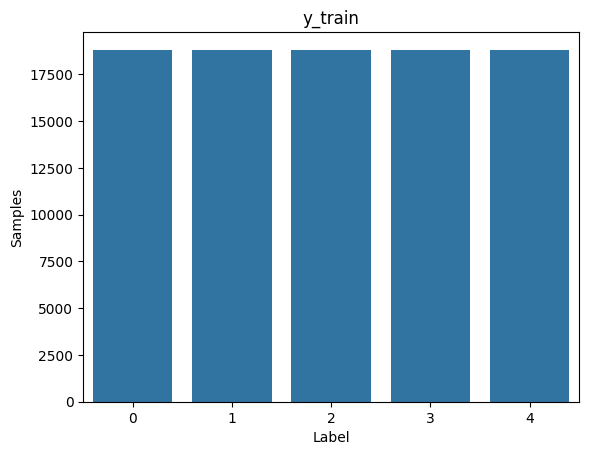

In [4]:
#Check if balancing worked
sns.countplot(x=y_train)
plt.title('y_train')
plt.xlabel('Label')
plt.ylabel('Samples')
plt.show()

### Optuna

In [5]:
# ---------------------------------------------------------
# 2. Define the Optuna Objective Function
# ---------------------------------------------------------
static_params = {
    "random_seed": 42,
    "verbose": False,
    "task_type": "GPU",
    "eval_metric": "TotalF1:average=Macro"
}

def objective(trial):
    # Define the hyperparameter search space
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
    }
    params.update(static_params)
    # Instantiate the model for this trial
    model = CatBoostClassifier(**params)

    # Fit the model using the Validation set for early stopping
    model.fit(
        X_train, 
        y_train,
        cat_features=categorical_features,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=100, 
        use_best_model=True
    )

    # Predict discrete classes, not probabilities
    preds_class = model.predict(X_val)
    preds_class = np.squeeze(preds_class) # Ensure flat 1D array
    
    # Calculate Macro F1
    macro_f1 = f1_score(y_val, preds_class, average='macro')
    
    return macro_f1

In [6]:
# ---------------------------------------------------------
# 3. Run the Optuna Study
# ---------------------------------------------------------
print("Starting Optuna hyperparameter tuning...")

# Suppress Optuna's verbose trial-by-trial logs if desired
# optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30) # Adjust n_trials based on your time constraints

print("\n--- Optimization Finished ---")
print(f"Best Validation Logloss: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-12 10:47:44,495] A new study created in memory with name: no-name-4d974323-f4ba-4694-b432-a72bc5b988ee


Starting Optuna hyperparameter tuning...


[I 2026-06-12 10:47:51,610] Trial 0 finished with value: 0.39634902794401694 and parameters: {'iterations': 627, 'learning_rate': 0.014812508348851438, 'depth': 4, 'l2_leaf_reg': 3.539283598590564, 'min_data_in_leaf': 7}. Best is trial 0 with value: 0.39634902794401694.
[I 2026-06-12 10:48:09,079] Trial 1 finished with value: 0.4426251971442987 and parameters: {'iterations': 1654, 'learning_rate': 0.06719904247426893, 'depth': 8, 'l2_leaf_reg': 1.5972436313618799, 'min_data_in_leaf': 6}. Best is trial 1 with value: 0.4426251971442987.
[I 2026-06-12 10:48:50,692] Trial 2 finished with value: 0.44455786496687083 and parameters: {'iterations': 1471, 'learning_rate': 0.06082795329167581, 'depth': 9, 'l2_leaf_reg': 7.22349832633326, 'min_data_in_leaf': 32}. Best is trial 2 with value: 0.44455786496687083.
[I 2026-06-12 10:49:23,485] Trial 3 finished with value: 0.44112759808006025 and parameters: {'iterations': 1903, 'learning_rate': 0.04171723605678562, 'depth': 7, 'l2_leaf_reg': 8.7806475


--- Optimization Finished ---
Best Validation Logloss: 0.4473
Best Parameters:
  iterations: 1812
  learning_rate: 0.09940185824542776
  depth: 7
  l2_leaf_reg: 2.9482986032866387
  min_data_in_leaf: 41


### Entrenamiento

In [7]:
# ---------------------------------------------------------
# 4. Train Final Model & Evaluate on Test Set
# ---------------------------------------------------------
print("\nTraining final model with best parameters...")

# Initialize the final model

final_params = study.best_params.copy()
final_params.update(static_params)
final_model = CatBoostClassifier(**final_params)

# Retrain using Train set and use Validation set for early stopping one last time
final_model.fit(
    X_train, 
    y_train,
    cat_features=categorical_features,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=100,
    use_best_model=True
)


Training final model with best parameters...


CatBoostClassifier(depth=7, eval_metric='TotalF1:average=Macro', iterations=1812, l2_leaf_reg=2.9482986032866387, learning_rate=0.09940185824542776, min_data_in_leaf=41, random_seed=42, task_type='GPU', verbose=False)

### Prediccion en Test

In [8]:
# Make final predictions on the completely unseen X_test
y_pred = final_model.predict(X_test)

# Print performance metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 0.7558

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88     86950
           1       0.56      0.71      0.62     17859
           2       0.23      0.29      0.26      7736
           3       0.18      0.31      0.22      2274
           4       0.17      0.44      0.24      1179

    accuracy                           0.76    115998
   macro avg       0.41      0.51      0.44    115998
weighted avg       0.81      0.76      0.78    115998



In [9]:
final_model.save_model("catboost_balanced_drop.cbm")

### Feature Importance

In [11]:
model = CatBoostClassifier().load_model("catboost_balanced_drop.cbm")

/tmp/ipykernel_23229/475268667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')


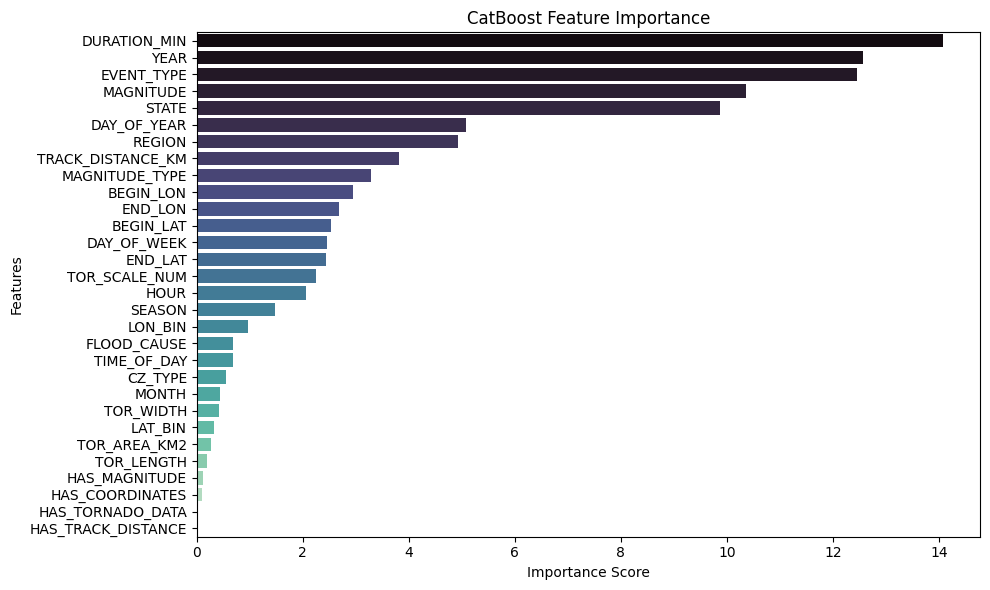

In [12]:
importances = model.get_feature_importance()
feature_names = model.feature_names_

# Pack them into a DataFrame for clean sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()